# Práctica: ML Clasificación  
## Programación de IA

**Alumno:** Fernando Yucsan Chang Cam

---

## Descripción del problema

Contamos con un conjunto de datos que contiene **12 características** que pueden usarse para predecir la **mortalidad por insuficiencia cardíaca**.

---

## Propiedades del dataset

- **edad**: edad del paciente.  
- **anemia**: indica si existe un decremento en el recuento de glóbulos rojos (hemoglobina).  
- **creatinina_fosfocinasa**: nivel de esta enzima en la sangre (mg/l).  
- **diabetes**: indica si el paciente sufre (1) o no (0) esta enfermedad.  
- **sangre_contraccion**: porcentaje del total de sangre que sale del corazón en cada contracción.  
- **tension**: especifica la tensión arterial mínima del paciente, siendo 12 una tensión normal y 20 una tensión muy alta.  
- **plaquetas**: cantidad de plaquetas en la sangre (K plaquetas/ml).  
- **creatinina**: nivel de creatinina en la sangre (mg/dl).  
- **sodio**: nivel de sodio en la sangre (mEq/l, miliequivalentes/litro).  
- **sexo**: especifica si el paciente es hombre (1) o mujer (0).  
- **fumador**: indica si es fumador y, en caso afirmativo, el número máximo de cigarrillos que fuma en una semana.  
- **seguimiento**: duración en días del seguimiento clínico.  
- **fallecimiento**: indica si el paciente ha muerto por ECV (1) o ha sobrevivido a la enfermedad (0).  
  - **Esta variable es el objetivo del modelo.**

---

## Objetivo de la práctica

La práctica consiste en **crear el mejor modelo posible**, utilizando los **estimadores vistos en clase**, que permita **predecir la supervivencia** de pacientes que han sufrido una enfermedad por insuficiencia cardíaca.

# PIPELINE DE ENTRENAMIENTO Y EVALUACIÓN DE MODELOS

## FASE 1: EVALUACIÓN Y COMPARACIÓN (con datos limitados)
```
FASE 1: EVALUACIÓN Y COMPARACIÓN
│
├─ train_test_split(X, y, 80/20) al INICIO
│
├─ Para cada uno de los 5 modelos:
│   │
│   ├─ Cross-validation SOLO con X_train (80%)
│   │
│   ├─ Entrenar modelo con X_train
│   │
│   ├─ y_pred = modelo.predict(X_test) ← Predicción HONESTA
│   │
│   ├─ classification_report(y_test, y_pred)
│   │
│   └─ Matriz de confusión con y_test
│
├─ Comparar los 5 modelos por sus test_scores
│
└─ Identificar GANADOR
```

## FASE 2: MODELO FINAL (con todos los datos)
```
FASE 2: MODELO FINAL
│
├─ Tomar el modelo GANADOR de Fase 1
│
├─ Entrenar con X_scaled completo (100% de datos)
│
├─ y_pred_final = modelo_ganador.predict(X_scaled)
│
├─ classification_report(y, y_pred_final) ← Métricas "optimistas"
│
└─ Matriz de confusión final
```

---

### Notas importantes:

- **Fase 1**: Evaluación justa con datos separados
- **Fase 2**: Entrenamiento final con dataset completo
- **Objetivo**: Maximizar rendimiento del modelo ganador

In [ ]:
# ============================================================================
# PRÁCTICA: CLASIFICACIÓN DE MORTALIDAD POR INSUFICIENCIA CARDÍACA
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("CLASIFICACIÓN DE MORTALIDAD POR INSUFICIENCIA CARDÍACA")
print("=" * 80)


CLASIFICACIÓN DE MORTALIDAD POR INSUFICIENCIA CARDÍACA


In [ ]:
# ============================================================================
# 1. CARGA Y EXPLORACIÓN DEL DATASET
# ============================================================================

print("\n[1] Cargando dataset...")
# Cargar datos
df = pd.read_csv('historial_clinico.csv')

print(f"✓ Dataset cargado: {df.shape[0]} pacientes, {df.shape[1]} columnas")
print(f"\nColumnas: {list(df.columns)}")

# Información básica
print("\n" + "-" * 80)
print("INFORMACIÓN DEL DATASET")
print("-" * 80)
print(df.info())

print("\n" + "-" * 80)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("-" * 80)
print(df.describe())

# Verificar valores nulos
print("\n" + "-" * 80)
print("VALORES NULOS")
print("-" * 80)
nulos = df.isnull().sum()
print(nulos)
if nulos.sum() == 0:
    print("✓ No hay valores nulos en el dataset")

# Distribución de la variable objetivo
print("\n" + "-" * 80)
print("DISTRIBUCIÓN DE LA VARIABLE OBJETIVO")
print("-" * 80)
print(df['fallecimiento'].value_counts())
print(f"\nSupervivientes: {(df['fallecimiento'] == 0).sum()} ({(df['fallecimiento'] == 0).mean() * 100:.2f}%)")
print(f"Fallecidos: {(df['fallecimiento'] == 1).sum()} ({(df['fallecimiento'] == 1).mean() * 100:.2f}%)")
print("\n⚠ Dataset desbalanceado detectado - Se usará estratificación")


[1] Cargando dataset...
✓ Dataset cargado: 299 pacientes, 13 columnas

Columnas: ['edad', 'creatinina_fosfocinasa', 'diabetes', 'sangre_contraccion', 'plaquetas', 'creatinina', 'sodio', 'seguimiento', 'fallecimiento', 'anemia', 'tension', 'sexo', 'fumador']

--------------------------------------------------------------------------------
INFORMACIÓN DEL DATASET
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   edad                    299 non-null    int64  
 1   creatinina_fosfocinasa  299 non-null    int64  
 2   diabetes                299 non-null    int64  
 3   sangre_contraccion      299 non-null    int64  
 4   plaquetas               299 non-null    float64
 5   creatinina              299 non-null    float64
 6   sodio               

In [ ]:
# ============================================================================
# 2. DIVISIÓN INICIAL: TRAIN (80%) / TEST (20%)
# ============================================================================

print("\n" + "=" * 80)
print("[2] División Train-Test (80/20)")
print("=" * 80)


semilla = 1
X = df.drop('fallecimiento', axis=1)
y = df['fallecimiento']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=semilla
)

print(f"Train: {X_train.shape[0]} pacientes")
print(f"Test:  {X_test.shape[0]} pacientes")

# Normalización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("✓ Datos normalizados")


[2] División Train-Test (80/20)
Train: 239 pacientes
Test:  60 pacientes
✓ Datos normalizados


In [ ]:
# ============================================================================
# 3. CONFIGURACIÓN DE VALIDACIÓN CRUZADA
# ============================================================================

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla)

# ============================================================================
# 4. EVALUACIÓN DE MODELOS (CON DATOS DE TRAIN)
# ============================================================================

print("\n" + "=" * 80)
print("[3] Evaluación de modelos con train-test honestos")
print("=" * 80)

resultados = {}


[3] Evaluación de modelos con train-test honestos



[4.1] MODELO-1: Regresión Logística
--------------------------------------------------------------------------------
CV Train: 0.8839
CV Test:  0.8617
Test Score: 0.9167

Classification Report:
               precision    recall  f1-score   support

Superviviente       0.93      0.95      0.94        41
    Fallecido       0.89      0.84      0.86        19

     accuracy                           0.92        60
    macro avg       0.91      0.90      0.90        60
 weighted avg       0.92      0.92      0.92        60



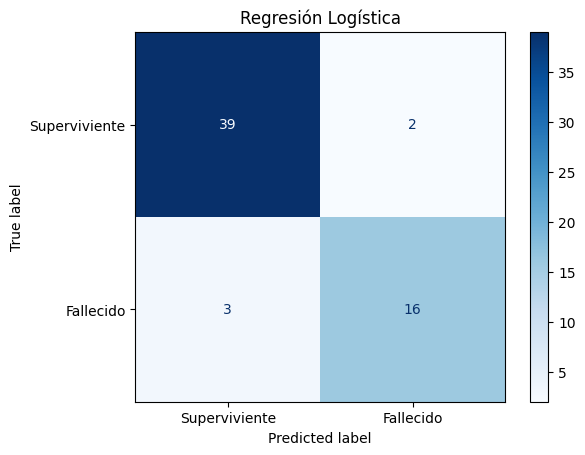

In [ ]:
# ----------------------------------------------------------------------------
# 4.1. REGRESIÓN LOGÍSTICA
# ----------------------------------------------------------------------------
print("\n[4.1] MODELO-1: Regresión Logística")
print("-" * 80)

log_reg = LogisticRegression(C=1.0, max_iter=1000, random_state=semilla)

cv_results = cross_validate(
    log_reg, X_train_scaled, y_train,
    cv=cv_strategy,
    scoring='accuracy',
    return_train_score=True
)

log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

resultados['Regresión Logística'] = {
    'modelo': log_reg,
    'cv_train': cv_results['train_score'].mean(),
    'cv_test': cv_results['test_score'].mean(),
    'test_score': log_reg.score(X_test_scaled, y_test)
}

print(f"CV Train: {cv_results['train_score'].mean():.4f}")
print(f"CV Test:  {cv_results['test_score'].mean():.4f}")
print(f"Test Score: {log_reg.score(X_test_scaled, y_test):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log, target_names=['Superviviente', 'Fallecido']))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, display_labels=['Superviviente', 'Fallecido'], cmap='Blues')
plt.title('Regresión Logística')
plt.show()


[4.2] MODELO-2: Análisis Discriminante Lineal (LDA)
--------------------------------------------------------------------------------
CV Train: 0.8881
CV Test:  0.8535
Test Score: 0.8833

Classification Report:
               precision    recall  f1-score   support

Superviviente       0.89      0.95      0.92        41
    Fallecido       0.88      0.74      0.80        19

     accuracy                           0.88        60
    macro avg       0.88      0.84      0.86        60
 weighted avg       0.88      0.88      0.88        60



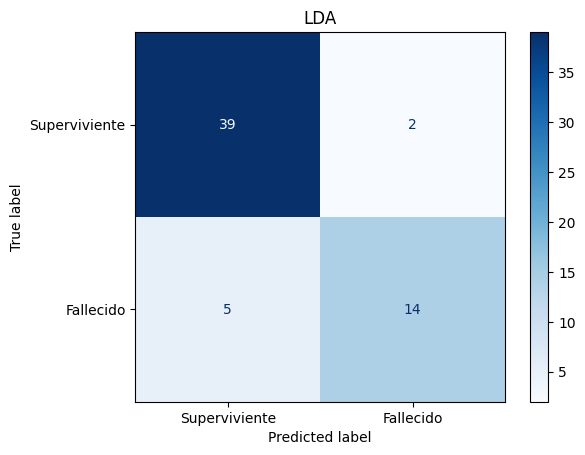

In [ ]:
# ----------------------------------------------------------------------------
# 4.2. ANÁLISIS DISCRIMINANTE LINEAL (LDA)
# ----------------------------------------------------------------------------
print("\n[4.2] MODELO-2: Análisis Discriminante Lineal (LDA)")
print("-" * 80)

lda = LinearDiscriminantAnalysis()

cv_results = cross_validate(
    lda, X_train_scaled, y_train,
    cv=cv_strategy,
    scoring='accuracy',
    return_train_score=True
)

lda.fit(X_train_scaled, y_train)
y_pred_lda = lda.predict(X_test_scaled)

resultados['LDA'] = {
    'modelo': lda,
    'cv_train': cv_results['train_score'].mean(),
    'cv_test': cv_results['test_score'].mean(),
    'test_score': lda.score(X_test_scaled, y_test)
}

print(f"CV Train: {cv_results['train_score'].mean():.4f}")
print(f"CV Test:  {cv_results['test_score'].mean():.4f}")
print(f"Test Score: {lda.score(X_test_scaled, y_test):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lda, target_names=['Superviviente', 'Fallecido']))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lda, display_labels=['Superviviente', 'Fallecido'], cmap='Blues')
plt.title('LDA')
plt.show()


[4.3] MODELO-3: Análisis Discriminante Cuadrático (QDA)
--------------------------------------------------------------------------------
CV Train: 0.8734
CV Test:  0.8200
Test Score: 0.8667

Classification Report:
               precision    recall  f1-score   support

Superviviente       0.87      0.95      0.91        41
    Fallecido       0.87      0.68      0.76        19

     accuracy                           0.87        60
    macro avg       0.87      0.82      0.84        60
 weighted avg       0.87      0.87      0.86        60



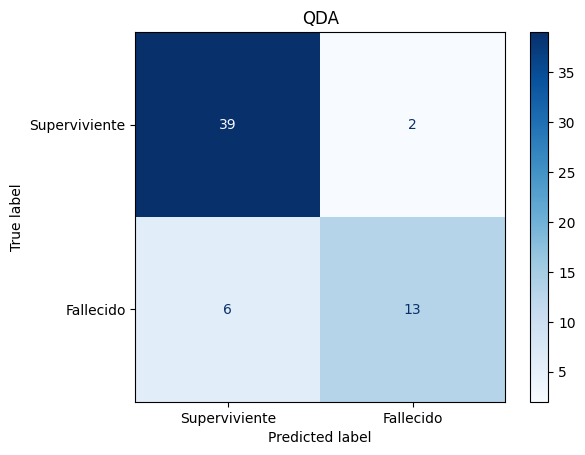

In [ ]:
# ----------------------------------------------------------------------------
# 4.3. ANÁLISIS DISCRIMINANTE CUADRÁTICO (QDA)
# ----------------------------------------------------------------------------
print("\n[4.3] MODELO-3: Análisis Discriminante Cuadrático (QDA)")
print("-" * 80)

qda = QuadraticDiscriminantAnalysis()

cv_results = cross_validate(
    qda, X_train_scaled, y_train,
    cv=cv_strategy,
    scoring='accuracy',
    return_train_score=True
)

qda.fit(X_train_scaled, y_train)
y_pred_qda = qda.predict(X_test_scaled)

resultados['QDA'] = {
    'modelo': qda,
    'cv_train': cv_results['train_score'].mean(),
    'cv_test': cv_results['test_score'].mean(),
    'test_score': qda.score(X_test_scaled, y_test)
}

print(f"CV Train: {cv_results['train_score'].mean():.4f}")
print(f"CV Test:  {cv_results['test_score'].mean():.4f}")
print(f"Test Score: {qda.score(X_test_scaled, y_test):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_qda, target_names=['Superviviente', 'Fallecido']))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_qda, display_labels=['Superviviente', 'Fallecido'], cmap='Blues')
plt.title('QDA')
plt.show()


[4.4] MODELO-4: SVC con GridSearchCV
--------------------------------------------------------------------------------
Mejores parámetros: C=1, kernel=rbf, gamma=scale
CV Train: 0.9309
CV Test:  0.8576
Test Score: 0.9167

Classification Report:
               precision    recall  f1-score   support

Superviviente       0.91      0.98      0.94        41
    Fallecido       0.94      0.79      0.86        19

     accuracy                           0.92        60
    macro avg       0.92      0.88      0.90        60
 weighted avg       0.92      0.92      0.91        60



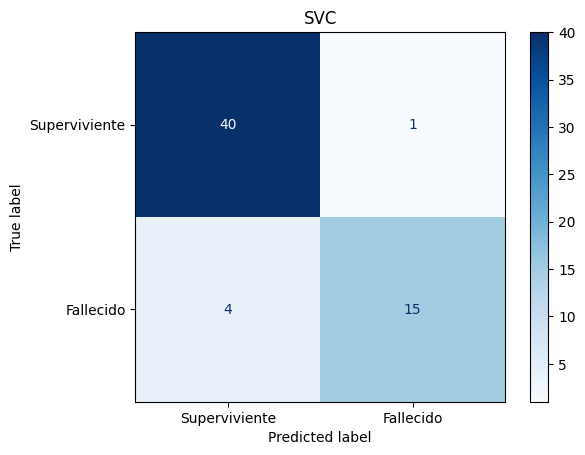

In [ ]:
# ----------------------------------------------------------------------------
# 4.4. SVC CON GRIDSEARCHCV
# ----------------------------------------------------------------------------
print("\n[4.4] MODELO-4: SVC con GridSearchCV")
print("-" * 80)

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

svc_base = SVC(random_state=semilla, probability=True)
grid_search = GridSearchCV(
    estimator=svc_base,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train_scaled, y_train)
svc = grid_search.best_estimator_

print(f"Mejores parámetros: C={grid_search.best_params_['C']}, kernel={grid_search.best_params_['kernel']}, gamma={grid_search.best_params_['gamma']}")

cv_results = cross_validate(
    svc, X_train_scaled, y_train,
    cv=cv_strategy,
    scoring='accuracy',
    return_train_score=True
)

y_pred_svc = svc.predict(X_test_scaled)

resultados['SVC'] = {
    'modelo': svc,
    'cv_train': cv_results['train_score'].mean(),
    'cv_test': cv_results['test_score'].mean(),
    'test_score': svc.score(X_test_scaled, y_test)
}

print(f"CV Train: {cv_results['train_score'].mean():.4f}")
print(f"CV Test:  {cv_results['test_score'].mean():.4f}")
print(f"Test Score: {svc.score(X_test_scaled, y_test):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svc, target_names=['Superviviente', 'Fallecido']))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svc, display_labels=['Superviviente', 'Fallecido'], cmap='Blues')
plt.title('SVC')
plt.show()


[4.5] MODELO-5: Árbol de Decisión
--------------------------------------------------------------------------------
CV Train: 0.9435
CV Test:  0.9287
Test Score: 0.9500

Classification Report:
               precision    recall  f1-score   support

Superviviente       1.00      0.93      0.96        41
    Fallecido       0.86      1.00      0.93        19

     accuracy                           0.95        60
    macro avg       0.93      0.96      0.94        60
 weighted avg       0.96      0.95      0.95        60



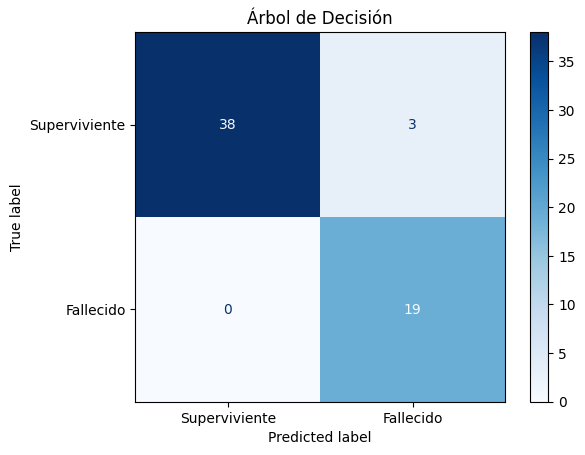

In [ ]:
# ----------------------------------------------------------------------------
# 4.5. ÁRBOL DE DECISIÓN
# ----------------------------------------------------------------------------
print("\n[4.5] MODELO-5: Árbol de Decisión")
print("-" * 80)

arbol = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=semilla
)

cv_results = cross_validate(
    arbol, X_train, y_train,
    cv=cv_strategy,
    scoring='accuracy',
    return_train_score=True
)

arbol.fit(X_train, y_train)
y_pred_arbol = arbol.predict(X_test)

resultados['Árbol de Decisión'] = {
    'modelo': arbol,
    'cv_train': cv_results['train_score'].mean(),
    'cv_test': cv_results['test_score'].mean(),
    'test_score': arbol.score(X_test, y_test)
}

print(f"CV Train: {cv_results['train_score'].mean():.4f}")
print(f"CV Test:  {cv_results['test_score'].mean():.4f}")
print(f"Test Score: {arbol.score(X_test, y_test):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_arbol, target_names=['Superviviente', 'Fallecido']))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_arbol, display_labels=['Superviviente', 'Fallecido'], cmap='Blues')
plt.title('Árbol de Decisión')
plt.show()

In [ ]:
# ============================================================================
# 5. COMPARACIÓN Y SELECCIÓN DEL MEJOR MODELO
# ============================================================================

print("\n" + "=" * 80)
print("[4] Comparación de modelos")
print("=" * 80)

print(f"\n{'Modelo':<25} {'CV Train':<12} {'CV Test':<12} {'Test Score':<12}")
print("-" * 80)
for nombre, metricas in resultados.items():
    print(f"{nombre:<25} {metricas['cv_train']:<12.4f} {metricas['cv_test']:<12.4f} {metricas['test_score']:<12.4f}")

mejor_nombre = max(resultados.items(), key=lambda x: x[1]['test_score'])[0]
mejor_info = resultados[mejor_nombre]

print(f"\n✓ Mejor modelo: {mejor_nombre}")
print(f"✓ Test Score: {mejor_info['test_score']:.4f}")


[4] Comparación de modelos

Modelo                    CV Train     CV Test      Test Score  
--------------------------------------------------------------------------------
Regresión Logística       0.8839       0.8617       0.9167      
LDA                       0.8881       0.8535       0.8833      
QDA                       0.8734       0.8200       0.8667      
SVC                       0.9309       0.8576       0.9167      
Árbol de Decisión         0.9435       0.9287       0.9500      

✓ Mejor modelo: Árbol de Decisión
✓ Test Score: 0.9500



[5] Entrenamiento del mejor modelo con 100% de datos
✓ Modelo entrenado con 299 pacientes
✓ Score final: 0.9130

--------------------------------------------------------------------------------
CLASSIFICATION REPORT FINAL
--------------------------------------------------------------------------------
               precision    recall  f1-score   support

Superviviente       0.90      0.99      0.94       203
    Fallecido       0.96      0.76      0.85        96

     accuracy                           0.91       299
    macro avg       0.93      0.87      0.89       299
 weighted avg       0.92      0.91      0.91       299


--------------------------------------------------------------------------------
MATRIZ DE CONFUSIÓN FINAL
--------------------------------------------------------------------------------
[[200   3]
 [ 23  73]]


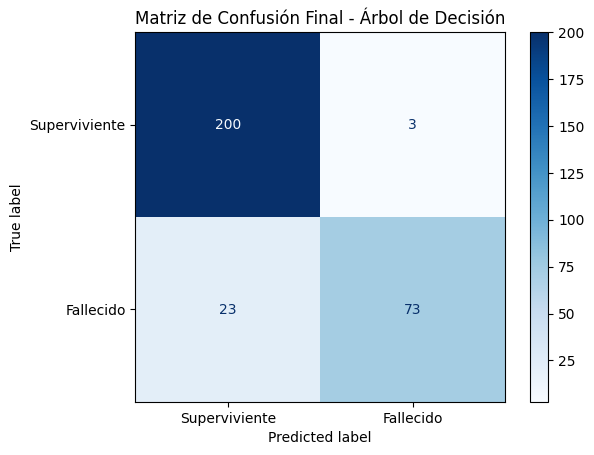

In [ ]:
# ============================================================================
# 6. ENTRENAMIENTO FINAL CON TODOS LOS DATOS (100%)
# ============================================================================

print("\n" + "=" * 80)
print("[5] Entrenamiento del mejor modelo con 100% de datos")
print("=" * 80)

scaler_final = StandardScaler()
X_scaled_completo = scaler_final.fit_transform(X)

if mejor_nombre == 'Árbol de Decisión':
    X_final = X
else:
    X_final = pd.DataFrame(X_scaled_completo, columns=X.columns)

modelo_final = mejor_info['modelo']
modelo_final.fit(X_final, y)

y_pred_final = modelo_final.predict(X_final)
score_final = modelo_final.score(X_final, y)

print(f"✓ Modelo entrenado con {X.shape[0]} pacientes")
print(f"✓ Score final: {score_final:.4f}")

print("\n" + "-" * 80)
print("CLASSIFICATION REPORT FINAL")
print("-" * 80)
print(classification_report(y, y_pred_final, target_names=['Superviviente', 'Fallecido']))

print("\n" + "-" * 80)
print("MATRIZ DE CONFUSIÓN FINAL")
print("-" * 80)
cm_final = confusion_matrix(y, y_pred_final)
print(cm_final)

ConfusionMatrixDisplay(cm_final, display_labels=['Superviviente', 'Fallecido']).plot(cmap='Blues')
plt.title(f'Matriz de Confusión Final - {mejor_nombre}')
plt.show()


[6] Generando visualización del árbol...


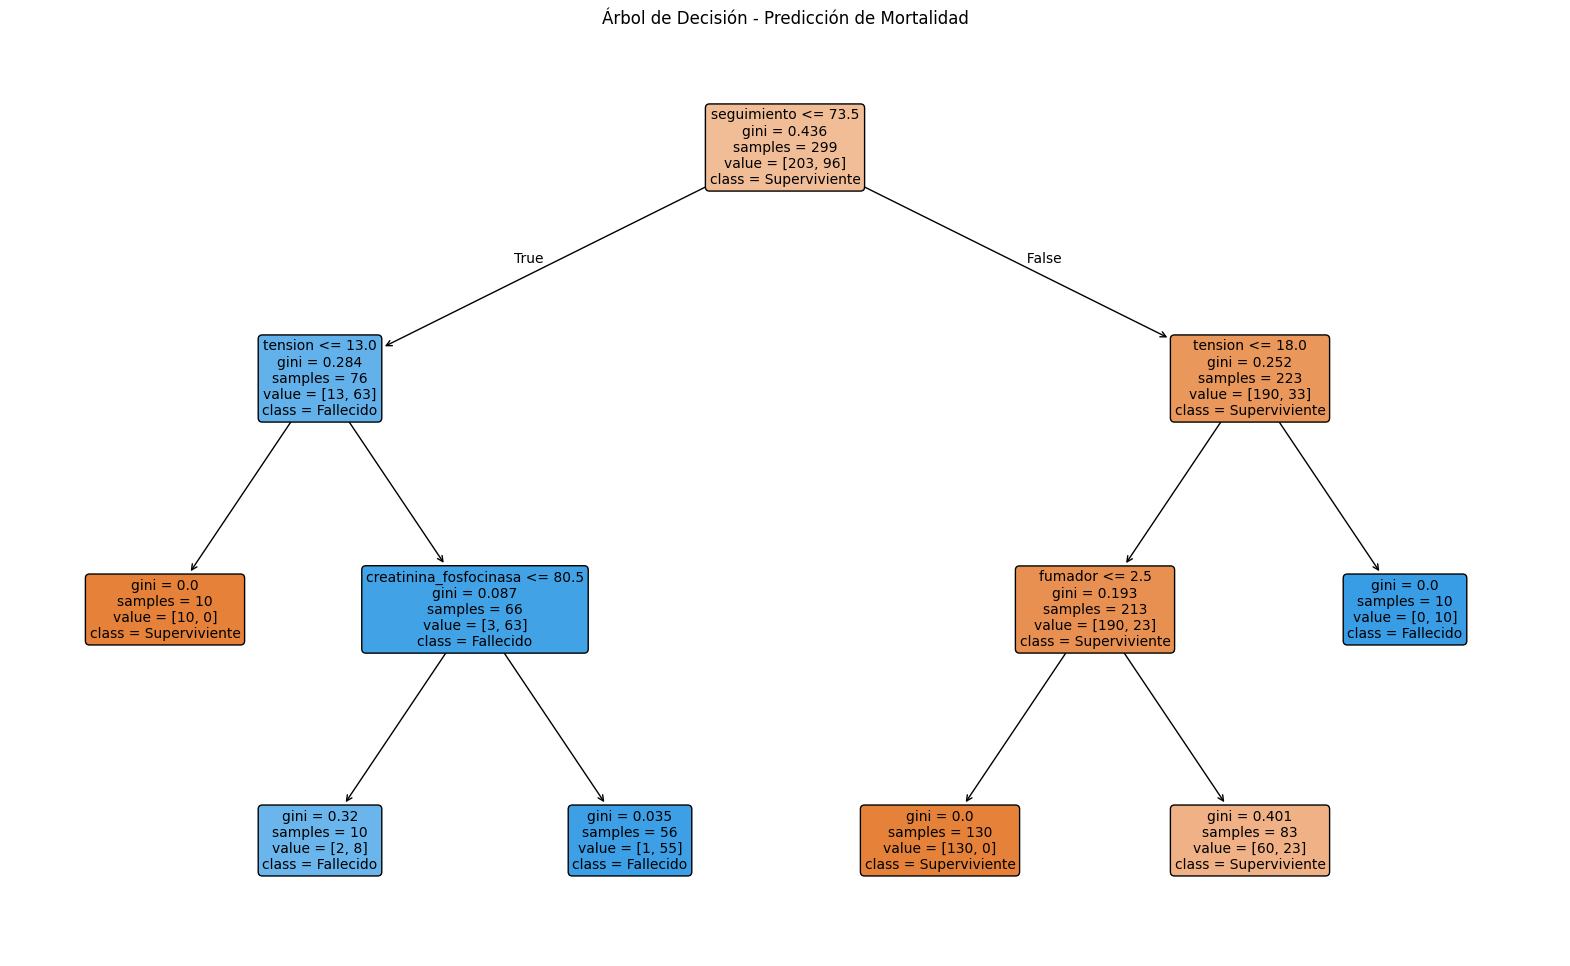

In [ ]:
# ============================================================================
# 7. VISUALIZACIÓN DEL ÁRBOL (si aplica)
# ============================================================================

if mejor_nombre == 'Árbol de Decisión':
    print("\n[6] Generando visualización del árbol...")
    plt.figure(figsize=(20, 12))
    plot_tree(
        modelo_final,
        feature_names=X.columns,
        class_names=['Superviviente', 'Fallecido'],
        filled=True,
        rounded=True,
        fontsize=10
    )
    plt.title('Árbol de Decisión - Predicción de Mortalidad')
    plt.show()

In [ ]:
# ============================================================================
# 8. RESUMEN FINAL
# ============================================================================

print("\n" + "=" * 80)
print("RESUMEN FINAL")
print("=" * 80)
print(f"""
Dataset: {df.shape[0]} pacientes, {df.shape[1]-1} características
Modelos evaluados: 5
División: 80% train, 20% test
Validación: Stratified K-Fold (5 splits)
Mejor modelo: {mejor_nombre}
Test Score (evaluación honesta): {mejor_info['test_score']:.4f}
Score final (100% datos): {score_final:.4f}

El modelo final fue entrenado con el 100% de los datos para maximizar
su capacidad predictiva, siguiendo la directriz de crear el mejor modelo posible.
""")
print("=" * 80)


RESUMEN FINAL

Dataset: 299 pacientes, 12 características
Modelos evaluados: 5
División: 80% train, 20% test
Validación: Stratified K-Fold (5 splits)
Mejor modelo: Árbol de Decisión
Test Score (evaluación honesta): 0.9500
Score final (100% datos): 0.9130

El modelo final fue entrenado con el 100% de los datos para maximizar
su capacidad predictiva, siguiendo la directriz de crear el mejor modelo posible.

